# Одноканальна система масового обслуговування

Необхідно промоделювати роботу одноканальної системи масового обслуговування на часовому інтервалі [0,T] (T - визначається користувачем). Задана періодичність збору статистики dt=T/K (задається користувачем). Для кожного моменту часу t= dt*i (i=0,...,K) необхідно обчислити такі характеристики:

1) час простою прибору tп; вірогідність простою прибору Pп=tп/t;
2) час завантаження прибору tз; вірогідність завантаження прибору Pз=tз/t.
3) кількість вимог, які були обслуговані до моменту часу t: Nо; вірогідність обслуговування Pо=Nо/N (N - кількість вимог, що поступили до системи);
4) кількість вимог, які залишили систему необслуговуваними до моменту t: Nн; вірогідність відмови Pн=Nн/N;
5) кількість вимог в системі (в черзі та на приборі) в момент часу t;
6) максимальна та середньозважена довжина черги;
7) середній час перебування вимог на приборі, у черзі, та в системі

Варіант №6

![title](img.png)

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
class SingleChannelQueue:
    def __init__(self, arrival_rate: float, queue_limit: int, time_limit: float, dt: float):
        """
        Initialize the single-channel queue system.
        :param arrival_rate: Arrival rate (lambda) for the Poisson process.
        :param queue_limit: Maximum queue size.
        :param time_limit: Simulation time limit.
        :param dt: Time step for recording statistics.
        """

        self.arrival_rate = arrival_rate
        self.queue_limit = queue_limit
        self.time_limit = time_limit
        self.dt = dt

        self.time = 0.0
        self.queue = []
        self.server_busy_until = 0.0

        self.total_requests = 0
        self.served_requests = 0
        self.dropped_requests = 0
        self.idle_time = 0.0
        self.queue_lengths = []
        self.system_times = []

    def generate_interarrival_time(self) -> float:
        return np.random.exponential(1 / self.arrival_rate)

    @staticmethod
    def generate_service_time() -> float:
        alpha = 1.5
        beta = 0.9
        return np.random.weibull(alpha) * beta

    def process_arrival(self, current_time: float):
        self.total_requests += 1

        if len(self.queue) < self.queue_limit:
            self.queue.append(current_time)
        else:
            self.dropped_requests += 1

    def process_service(self, current_time: float):
        if current_time >= self.server_busy_until:
            if self.queue:
                arrival_time = self.queue.pop(0)
                service_time = self.generate_service_time()
                self.server_busy_until = current_time + service_time
                self.served_requests += 1
                self.system_times.append(current_time - arrival_time + service_time)
            else:
                self.idle_time += self.dt

    def record_statistics(self):
        self.queue_lengths.append(len(self.queue))

    def simulate(self):
        next_arrival = self.generate_interarrival_time()

        self.time += self.dt
        while self.time < self.time_limit:
            if self.time >= next_arrival:
                self.process_arrival(self.time)
                next_arrival += self.generate_interarrival_time()

            self.process_service(self.time)
            self.record_statistics()
            self.time += self.dt

    def calculate_statistics(self) -> tuple[float, ...]:
        """
        Calculate key statistics for the system.

        :return: Tuple containing idle probability, load probability,
                 loss probability, mean queue length, mean system time,
                 mean time in queue, mean time in service.
        """
        total_time = self.time_limit
        idle_probability = self.idle_time / total_time
        load_probability = 1 - idle_probability
        loss_probability = self.dropped_requests / self.total_requests
        mean_queue_length = np.mean(self.queue_lengths)
        mean_system_time = np.mean(self.system_times)
        mean_time_in_queue = mean_system_time - np.mean([self.generate_service_time() for _ in range(100)])
        mean_time_in_service = mean_system_time - mean_time_in_queue

        return (
            idle_probability,
            load_probability,
            loss_probability,
            mean_queue_length,
            mean_system_time,
            mean_time_in_queue,
            mean_time_in_service,
        )

    def plot_statistics(self):
        time_steps = np.arange(0, self.time_limit, self.dt)
        plt.figure(figsize=(10, 5))
        plt.plot(time_steps, self.queue_lengths, label="Queue Length")
        plt.title("Queue Length Over Time")
        plt.xlabel("Time")
        plt.ylabel("Queue Length")
        plt.legend()
        plt.grid()
        plt.show()

Idle Probability: 0.5790000000000055
Load Probability: 0.4209999999999945
Loss Probability: 0.0
Mean Queue Length: 0.32
Mean System Time: 1.4423646933169751
Mean Time in Queue: 0.6120374522054215
Mean Time in Service: 0.8303272411115536


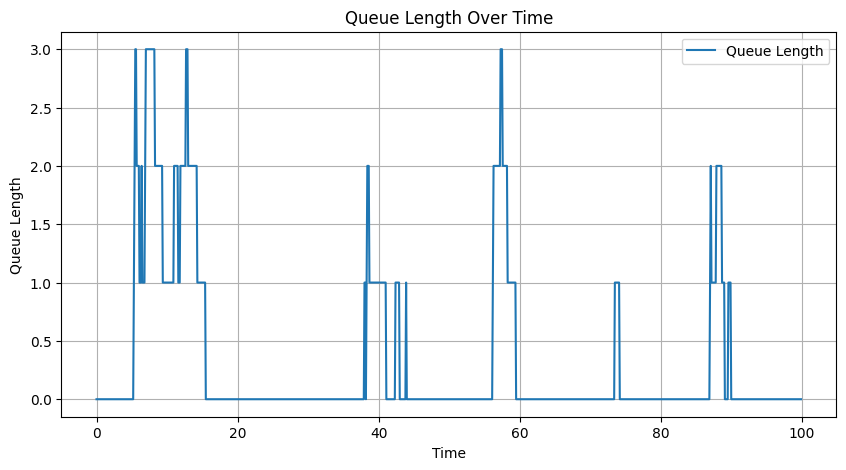

In [19]:
queue_system = SingleChannelQueue(
    arrival_rate=0.6,
    queue_limit=10,
    time_limit=100.0,
    dt=0.1,
)
queue_system.simulate()

stats = queue_system.calculate_statistics()
print("Idle Probability:", stats[0])
print("Load Probability:", stats[1])
print("Loss Probability:", stats[2])
print("Mean Queue Length:", stats[3])
print("Mean System Time:", stats[4])
print("Mean Time in Queue:", stats[5])
print("Mean Time in Service:", stats[6])

queue_system.plot_statistics()